# MCA eConsultation Sentiment AnalysisPredicts Positive / Negative / Neutral sentiment on comments submitted for a proposed MCA rule, generates a word cloud, and a short summary report.**Fixes applied in this version:**- Modular, reusable preprocessing pipeline (easy to add/remove cleaning steps)- Train/val/test split done BEFORE augmentation (fixes data leakage)- Word cloud + summary report added at the end

## 1. Mount Google Drive

In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Check GPU

## 3. Install required packages

In [3]:
!pip install -q datasets torch scikit-learn pandas numpy matplotlib seaborn wordcloud nltk emoji accelerate nlpaug

# !pip install wandb --upgrade
!pip uninstall -y transformers
!pip uninstall -y transformers

!pip install --upgrade transformers==4.56.0


import nltk
nltk.download('punkt')
nltk.download('stopwords')

# import wandb
# wandb.login()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 kB 38.1 MB/s eta 0:00:00
Found existing installation: transformers 5.15.1
Uninstalling transformers-5.15.1:
  Successfully uninstalled transformers-5.15.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 107.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.28.0
    Uninstalling huggingface_hub-1.28.0:
      Successfully uninstalled huggingface_hub-1.28.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.26.0 requires huggingface-hub<2.0,>=1.16.0, but you have huggingface-hub 0.36.2 which is inc

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 4. Load the datasetCSV must have two columns: `comment` and `sentiment` (positive/negative/neutral).

In [4]:
import pandas as pd
import re
import emoji
from nltk.corpus import stopwords

file_path = "/content/drive/MyDrive/mca_econsultation_leakage_free/comments_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,id,comment,sentiment
0,1,Portal frequently crashes under Secretarial St...,negative
1,2,Lacks clarity on penalties,negative
2,3,Confusing requirements under Companies Act,negative
3,4,Our company seek clarification on requirements...,neutral
4,5,More paperwork required under Corporate Govern...,negative



## 5. Preprocessing pipeline (modular)Instead of writing cleaning steps as loose code, each cleaning technique is its own small function ("step").They are chained together in a list. This makes it easy to:- add a new step later (e.g. remove stopwords, handle Hindi text) without touching old code- remove a step you don't want anymore- explain the pipeline clearly in an interview: "here is my list of steps, each one does one job"

In [7]:
import re
import emoji
# ---- Each function below is ONE cleaning step ----
def remove_emoji_step(text):
      return emoji.replace_emoji(text, replace='')
def remove_special_chars_step(text):
      return re.sub(r'[^a-zA-Z0-9\s!?]', '', text)
def lowercase_step(text):
      return text.lower().strip()
# ---- The pipeline: an ordered list of steps ----
# To add a new cleaning technique later: write a function like the ones# above, then just add it to this list (or remove one you don't want).
PREPROCESSING_PIPELINE = [
    remove_emoji_step,
    remove_special_chars_step,
    lowercase_step,
  ]
def preprocess(text, pipeline=PREPROCESSING_PIPELINE):
    for step in pipeline:
        text = step(text)
    return text
# Quick test
print(preprocess("This is AMAZING!! 😍😍 Very good work #MCA21"))

this is amazing!!  very good work mca21


In [8]:
df['clean_comment'] = df['comment'].apply(preprocess)
df[['comment', 'clean_comment']].head()

,comment,clean_comment
0,Portal frequently crashes under Secretarial St...,portal frequently crashes under secretarial st...
1,Lacks clarity on penalties,lacks clarity on penalties
2,Confusing requirements under Companies Act,confusing requirements under companies act
3,Our company seek clarification on requirements...,our company seek clarification on requirements...
4,More paperwork required under Corporate Govern...,more paperwork required under corporate govern...


## 6. Map sentiment labels to numbersDone once, right after cleaning, so train/val/test all share the same label format.

In [9]:
sentiment_map = {"negative": 0, "neutral": 1, "positive": 2}
label_mapping = {0: "Negative", 1: "Neutral", 2: "Positive"}

df['label'] = df['sentiment'].map(sentiment_map)
df[['clean_comment', 'sentiment', 'label']].head()

,clean_comment,sentiment,label
0,portal frequently crashes under secretarial st...,negative,0
1,lacks clarity on penalties,negative,0
2,confusing requirements under companies act,negative,0
3,our company seek clarification on requirements...,neutral,1
4,more paperwork required under corporate govern...,negative,0


## 7. Split into train / val / test — BEFORE augmentationThis is the key fix. We split on the **original, clean comments only**.Val and test will never contain any augmented (paraphrased) text, so they give an honest score.

In [10]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print("Train (original):", len(train_df))
print("Val (original, untouched):", len(val_df))
print("Test (original, untouched):", len(test_df))

Train (original): 4000
Val (original, untouched): 500
Test (original, untouched): 500


## 8. Augmentation pipeline (train set only)Same idea as the preprocessing pipeline — each augmentation technique is its own function,so you can add/remove techniques easily. This only ever runs on `train_df`.

In [12]:
import random
import nlpaug.augmenter.word as naw

syn_aug = naw.SynonymAug(aug_src='wordnet')

def synonym_replacement(text):
    try:
        return syn_aug.augment(text)
    except Exception:
        return text

def random_insertion(text):
    words = text.split()
    if len(words) < 2:
        return text
    insert_pos = random.randint(0, len(words) - 1)
    insert_word = random.choice(words)
    words.insert(insert_pos, insert_word)
    return ' '.join(words)

def random_swap(text):
    words = text.split()
    if len(words) < 2:
        return text
    idx1, idx2 = random.sample(range(len(words)), 2)
    words[idx1], words[idx2] = words[idx2], words[idx1]
    return ' '.join(words)

def random_deletion(text, p=0.2):
    words = text.split()
    if len(words) == 0:
        return text
    new_words = [w for w in words if random.random() > p]
    if len(new_words) == 0:
        return random.choice(words)
    return ' '.join(new_words)

AUGMENTATION_STEPS = [synonym_replacement, random_insertion, random_swap, random_deletion]

neutral_keywords = ['uncertain', 'not sure', 'confusing', 'doubt', 'unclear']

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [13]:
augmented_comments = []
augmented_labels = []

for idx, row in train_df.iterrows():
    comment = row['clean_comment']
    label = row['label']

    # keep the original
    augmented_comments.append(comment)
    augmented_labels.append(label)

    # apply every augmentation step
    for step in AUGMENTATION_STEPS:
        augmented_comments.append(step(comment))
        augmented_labels.append(label)

    # extra augmentation only for neutral comments
    if label == sentiment_map['neutral']:
        for kw in neutral_keywords:
            augmented_comments.append(comment + " " + kw)
            augmented_labels.append(label)

train_aug_df = pd.DataFrame({
    'clean_comment': augmented_comments,
    'label': augmented_labels
})

print("Train size after augmentation:", len(train_aug_df))

Streaming output truncated to the last 5000 lines.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_dat

Train size after augmentation: 27910


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger t

In [14]:
train_aug_df.to_csv("/content/drive/MyDrive/mca_econsultation_leakage_free/train_augmented.csv", index=False)
print("Augmented train set saved!")

Augmented train set saved!


## 9. Final train/val/test text and labelsval and test are used exactly as split — no augmentation applied to them.

In [15]:
train_texts, train_labels = train_aug_df['clean_comment'], train_aug_df['label']
val_texts, val_labels = val_df['clean_comment'], val_df['label']
test_texts, test_labels = test_df['clean_comment'], test_df['label']

## 10. TokenizeDistilBERT tokenizer turns each comment into numbers the model can read.

In [16]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(list(train_texts), truncation=True, padding="max_length", max_length=90)
val_encodings = tokenizer(list(val_texts), truncation=True, padding="max_length", max_length=90)
test_encodings = tokenizer(list(test_texts), truncation=True, padding="max_length", max_length=90)

## 11. PyTorch dataset wrapper

In [17]:
import torch
class FeedbackDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels.iloc[idx])
        return item

train_dataset = FeedbackDataset(train_encodings, train_labels)
val_dataset = FeedbackDataset(val_encodings, val_labels)
test_dataset = FeedbackDataset(test_encodings, test_labels)

## 12. Load DistilBERT for 3-class classification

In [18]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=3)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 13. Training setup

In [20]:
from transformers import Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='weighted')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

OUTPUT_DIR = '/content/drive/MyDrive/mca_econsultation_leakage_free/Sentimental_comments/results'
LOG_DIR = '/content/drive/MyDrive/mca_econsultation_leakage_free/Sentimental_comments//logs'

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir=LOG_DIR,
    learning_rate=3e-5,
    load_best_model_at_end=True,
    save_total_limit=3,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

## 14. Train the model

In [21]:
trainer.train()

/usr/local/lib/python3.13/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.012900,0.000112,1.000000,1.000000,1.000000,1.000000
2,0.006800,0.000035,1.000000,1.000000,1.000000,1.000000
3,0.002600,0.000025,1.000000,1.000000,1.000000,1.000000


TrainOutput(global_step=5235, training_loss=0.015930281008781425, metrics={'train_runtime': 722.3588, 'train_samples_per_second': 115.912, 'train_steps_per_second': 7.247, 'total_flos': 1949711676071400.0, 'train_loss': 0.015930281008781425, 'epoch': 3.0})

## 15. Evaluate on test set (honest score, no leakage)

In [22]:
metrics = trainer.evaluate(test_dataset)
print("Final Test Metrics:", metrics)

Final Test Metrics: {'eval_loss': 2.4980914531624876e-05, 'eval_accuracy': 1.0, 'eval_precision': 1.0, 'eval_recall': 1.0, 'eval_f1': 1.0, 'eval_runtime': 1.3795, 'eval_samples_per_second': 362.459, 'eval_steps_per_second': 23.197, 'epoch': 3.0}


## 16. Save the final model

In [23]:
final_model_dir = "/content/drive/MyDrive/mca_econsultation_leakage_free/Sentimental_comments/final_model"
model.save_pretrained(final_model_dir)
tokenizer.save_pretrained(final_model_dir)
print("Model saved to:", final_model_dir)

Model saved to: /content/drive/MyDrive/mca_econsultation_leakage_free/Sentimental_comments/final_model


## 17. Predict functionOne function that takes raw text in, and gives a sentiment label out. Reuses the same `preprocess()` pipeline from Step 5, so cleaning is always consistent.

In [29]:
def predict_sentiment(text):
    text = preprocess(text)
    inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True, max_length=90)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}   # move inputs to same device as model
    with torch.no_grad():
        outputs = model(**inputs)
        pred_class = torch.argmax(outputs.logits, dim=1).item()
    return label_mapping[pred_class]

# ---- Test 1: tricky, human-style comments (not from your dataset) ----
tricky_examples = [
    "well i guess this is fine, nothing special though",
    "not bad but could definitely be better honestly",
    "this update is a joke, absolutely useless",
    "not sure if this is good or bad tbh",
    "could be worse i guess",
    "honestly expected more from this",
    "it's okay, does the job",
    "meh, seen better",
    "great idea but poor execution",
    "this is fine for now, will see later",
    "somewhat helpful but confusing in parts",
    "no complaints so far",
    "guess we'll have to wait and see",
]

print("----- Tricky / human-style examples -----")
for c in tricky_examples:
    print(c, "->", predict_sentiment(c))

# ---- Test 2: random comments picked from your own dataset ----
random_samples = df.sample(5, random_state=None)   # change random_state to a number to repeat same sample

print("\n----- Random samples from dataset -----")
for _, row in random_samples.iterrows():
    predicted = predict_sentiment(row['comment'])
    print(f"Comment: {row['comment']}")
    print(f"Actual label: {row['sentiment']}  |  Predicted: {predicted}\n")

----- Tricky / human-style examples -----
well i guess this is fine, nothing special though -> Negative
not bad but could definitely be better honestly -> Negative
this update is a joke, absolutely useless -> Negative
not sure if this is good or bad tbh -> Neutral
could be worse i guess -> Negative
honestly expected more from this -> Neutral
it's okay, does the job -> Positive
meh, seen better -> Neutral
great idea but poor execution -> Negative
this is fine for now, will see later -> Positive
somewhat helpful but confusing in parts -> Negative
no complaints so far -> Negative
guess we'll have to wait and see -> Neutral

----- Random samples from dataset -----
Comment: Query about compliance timeline for CSR Rules
Actual label: neutral  |  Predicted: Neutral

Comment: Clarify documentation requirements for IBC
Actual label: neutral  |  Predicted: Neutral

Comment: Seek clarification on requirements for Director Liability
Actual label: neutral  |  Predicted: Neutral

Comment: Seeking cl

## 18. Predict sentiment for every comment (simulating the MCA platform use case)This is the part that answers the real project goal: given all comments on a proposed rule, how many are positive, negative, and neutral?

In [30]:
df['predicted_sentiment'] = df['clean_comment'].apply(lambda t: predict_sentiment(t))
sentiment_counts = df['predicted_sentiment'].value_counts()
print(sentiment_counts)

predicted_sentiment
Neutral     1977
Positive    1516
Negative    1507
Name: count, dtype: int64


## 19. Bar chart of sentiment counts

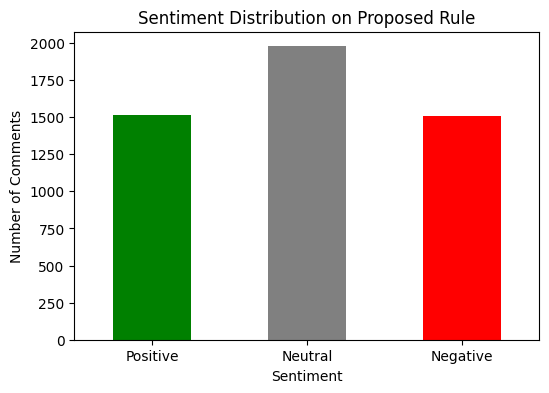

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sentiment_counts.reindex(["Positive", "Neutral", "Negative"]).plot(kind='bar', color=['green', 'gray', 'red'])
plt.title("Sentiment Distribution on Proposed Rule")
plt.xlabel("Sentiment")
plt.ylabel("Number of Comments")
plt.xticks(rotation=0)
plt.show()

## 20. Word cloud (overall, and per sentiment)

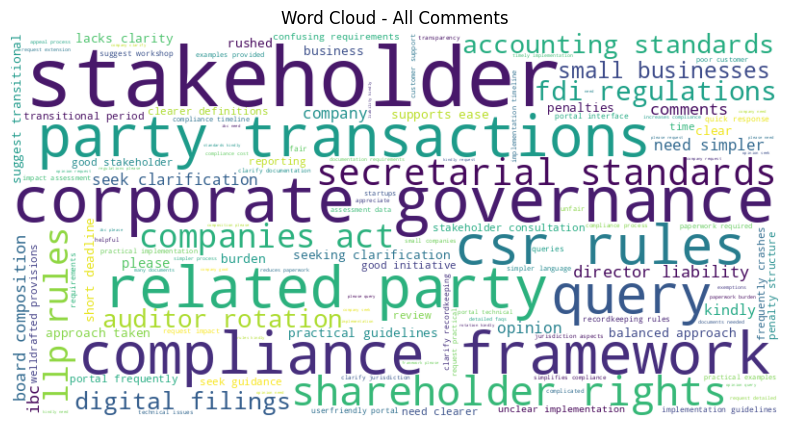

In [32]:
from wordcloud import WordCloud
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def make_wordcloud(text_series, title):
    text = " ".join(text_series.tolist())
    wc = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Overall word cloud
make_wordcloud(df['clean_comment'], "Word Cloud - All Comments")

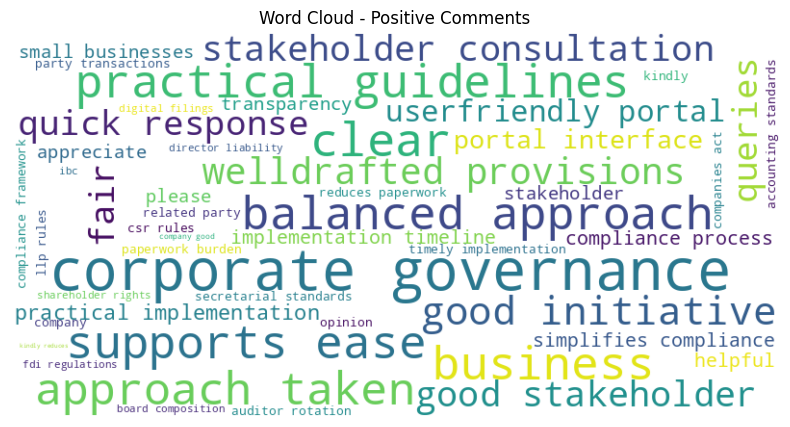

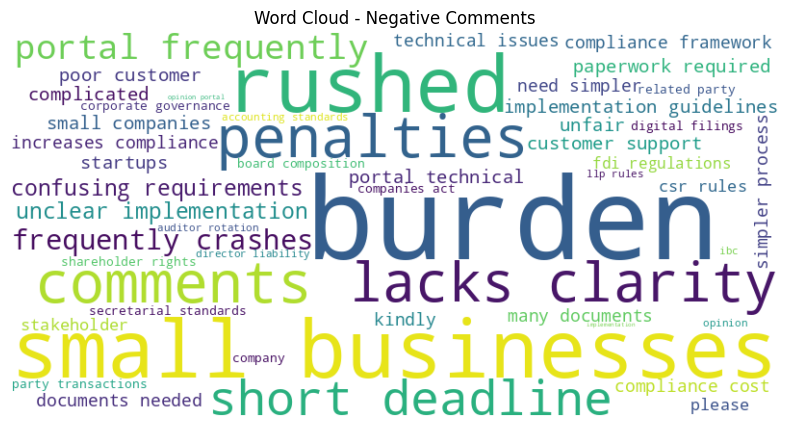

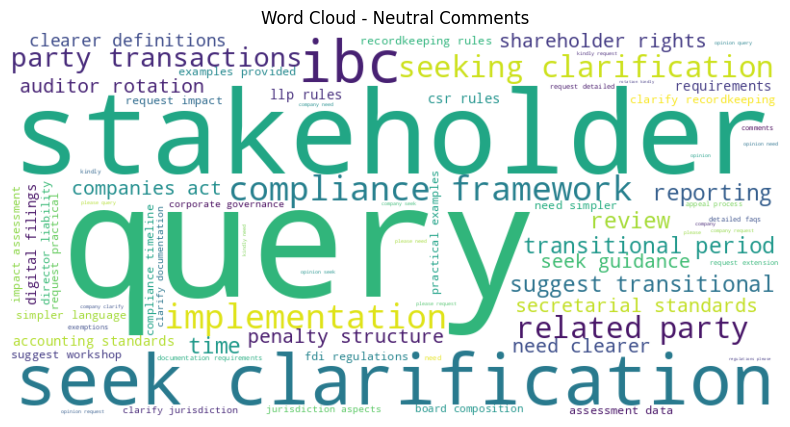

In [33]:
# Word cloud for each sentiment separately
for sentiment in ["Positive", "Negative", "Neutral"]:
    subset = df[df['predicted_sentiment'] == sentiment]['clean_comment']
    if len(subset) > 0:
        make_wordcloud(subset, f"Word Cloud - {sentiment} Comments")

## 21. Simple summary reportA short, human-readable summary of what people are saying — counts plus the most common words per sentiment. (No extra model needed — this uses word frequency, kept simple on purpose.)

In [34]:
from collections import Counter

def top_words(text_series, n=8):
    words = " ".join(text_series.tolist()).split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return [w for w, _ in Counter(words).most_common(n)]

total = len(df)
print("===== MCA eConsultation - Comment Summary Report =====")
print(f"Total comments analyzed: {total}\n")

for sentiment in ["Positive", "Negative", "Neutral"]:
    subset = df[df['predicted_sentiment'] == sentiment]
    pct = (len(subset) / total) * 100
    print(f"{sentiment}: {len(subset)} comments ({pct:.1f}%)")
    print(f"  Common words: {', '.join(top_words(subset['clean_comment']))}\n")

===== MCA eConsultation - Comment Summary Report =====
Total comments analyzed: 5000

Positive: 1516 comments (30.3%)
  Common words: practical, good, stakeholder, implementation, corporate, governance, compliance, rules

Negative: 1507 comments (30.1%)
  Common words: implementation, small, portal, compliance, companies, rules, standards, burden

Neutral: 1977 comments (39.5%)
  Common words: need, request, rules, clarification, seek, query, clarify, compliance



## Notes- The `PREPROCESSING_PIPELINE` list (Step 5) and `AUGMENTATION_STEPS` list (Step 8) are the two places to add/remove techniques — no other code needs to change.- Test accuracy in Step 15 is now honest (train/val/test never share augmented duplicates).- Step 18 re-predicts on the full original dataset just to build the summary report — in a real deployment this would run on newly submitted comments instead.